so watch me recreate this fractional cover mapping of the whole area for Hawai'i
1st we have to find out the coordinates for our bounding box

In [ ]:
import geopandas as gpd

# Load the shapefile
gdf = gpd.read_file('/Users/gillopez00/Downloads/2020_Census_County_Boundaries/2020_Census_County_Boundaries.shp')
# Get the bounding box (minx, miny, maxx, maxy)
bounds = gdf.total_bounds
print(bounds)  # array([minx, miny, maxx, maxy])


minx, miny, maxx, maxy = bounds

[ 371245.5627 2094230.8512  940276.089  2458639.7979]


^DO NOT RUN THIS!!! This was just a fancy code to get the coordinates for my bounding box; below it is more of an explanation; skip to Import Libraries but make sure that your kernel is set to Python 3.12 otherwise they will not run

# Hashtag thank you to Tamara who helped me find out this coordinates for the bounding box of the islands of Hawai'i; basically what we did together was going to claude to ask it how I can get the coordinates from here in QGIS then, Claude gave me the code above ^ to do so 
All we had to do was figure out how to change the path file from the template to mine which tamara taught me by literally Command + C (on mac) basically and it produced the numbers for me 
[ 371245.5627 2094230.8512  940276.089  2458639.7979]
(West boundary, South boundary, East boundary, North boundary)

In [2]:
# Import Libraries
import os
import earthaccess
import numpy as np
import geopandas as gpd
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
# QC flag codes -- from singleband_raster_hierarchy() in create_frcov_masks.py,
# https://github.com/emit-sds/emit-sds-frcov (not formally published in the User Guide).
# Hierarchical: each pixel gets the FIRST condition below that applies to it.
flag_labels = {
    0: "clear",
    1: "cloud_or_cirrus",
    2: "urban",
    3: "water_or_coastal",
    4: "snow_ice",
}  # -9999 = nodata (outside scene footprint); handled separately via masked=True on load

flag_colors = ["#2ca02c", "#7f7f7f", "#d62728", "#1f77b4", "#f2f2f2"]
cmap = ListedColormap(flag_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

In [4]:
# Authenticate with NASA Earthdata (reads ~/.netrc, or prompts + persists on first run)
auth = earthaccess.login(persist=True)

In [5]:
# EMIT L2B Fractional Cover & Uncertainty (60 m, V001) over Maui.
# Currently narrowed to the exact acquisition date (2025-08-17) of the granule from
# https://search.earthdata.nasa.gov/...&g=G3991818701-LPCLOUD -- widen `temporal`
# (e.g. back to a month-long window) to search more broadly.
bbox = (-160.245911, 18.910690, -154.806622, 22.232707)  # (lon_min, lat_min, lon_max, lat_max) (West, South, East, North) in decimal degrees/boundaries
temporal = ("2023-01-31", "2023-12-31")  # (start_date, end_date) in YYYY-MM-DD format

results = earthaccess.search_data(
    concept_id="C3911089796-LPCLOUD",  # EMIT_L2BFRCOV.001 collection (LPCLOUD)
    bounding_box=bbox,
    temporal=temporal,
)

print(f"Found {len(results)} granule(s)")

Found 47 granule(s)


/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


#ok so i have to rework my first line of code to make sure that the coordinates are within the 0-180 format which I re-ran to Claude about and it gave me this instead to run

In [10]:
import geopandas as gpd

import earthaccess
earthaccess.login()

In [8]:
# Load the shapefile
gdf = gpd.read_file('/Users/gillopez/Downloads/testing1/Scripts/2020_Census_County_Boundaries/2020_Census_County_Boundaries.shp')

# Check the original CRS (useful to confirm what you're starting from)
print("Original CRS:", gdf.crs)

# Reproject to WGS84 (EPSG:4326) — the lat/lon system earthaccess expects
gdf_wgs84 = gdf.to_crs(epsg=4326)

# Get the bounding box in lon/lat
minx, miny, maxx, maxy = gdf_wgs84.total_bounds
print(f"lon_min: {minx:.6f}, lat_min: {miny:.6f}, lon_max: {maxx:.6f}, lat_max: {maxy:.6f}")

Original CRS: EPSG:3750
lon_min: -160.245911, lat_min: 18.910690, lon_max: -154.806622, lat_max: 22.232707


make sure to run the first 2 packages then this line of code that Claude gave me

Okay so sadly, this produced 0 granules... for the ENTIRE YEAR OF 2022
We tried going a year back (2021) but again 0 granules found... so moved forward to 2023 and found 47 granules!!! We will just rename this to 2023 then

In [6]:
# Print every file (granule ID + all associated data/browse links) found in the search
for granule in results:
    print(granule["meta"]["native-id"])
    for link in granule.data_links():
        print(f"  {link}")

EMIT_L2B_FRCOV_001_20230219T002729_2304916_002
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20230219T002729_2304916_002/EMIT_L2B_FRCOVQC_001_20230219T002729_2304916_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20230219T002729_2304916_002/EMIT_L2B_FRCOVPV_001_20230219T002729_2304916_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20230219T002729_2304916_002/EMIT_L2B_FRCOVPVUNC_001_20230219T002729_2304916_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20230219T002729_2304916_002/EMIT_L2B_FRCOVNPV_001_20230219T002729_2304916_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20230219T002729_2304916_002/EMIT_L2B_FRCOVNPVUNC_001_20230219T002729_2304916_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-p

## Step 2: Locally download granules of interest

For every granule the search above found, there are 7 GeoTIFFs to download. Load them into one
 `xarray.Dataset`, and apply the QC band as a mask across the fraction
(PV/NPV/BARE) and uncertainty bands.

In [7]:
def download_and_reconcile(granule):
    """Download a granule's 7 GeoTIFFs, load into one aligned Dataset, mask
    fraction + uncertainty bands to QC-clear pixels (qc == 0). Returns (ds, ds_clear).
    QC flag source: create_frcov_masks.py in github.com/emit-sds/emit-sds-frcov."""
    granule_id = granule["meta"]["native-id"]
    out_dir = os.path.join("data", "emit_fcov", granule_id)
    os.makedirs(out_dir, exist_ok=True)
    files = earthaccess.download([granule], local_path=out_dir)

    roles = {}
    for f in files:
        name = os.path.basename(f)
        if "FRCOVQC" in name:
            roles["qc"] = f
        elif "FRCOVPVUNC" in name:
            roles["pv_unc"] = f
        elif "FRCOVNPVUNC" in name:
            roles["npv_unc"] = f
        elif "FRCOVBAREUNC" in name:
            roles["bare_unc"] = f
        elif "FRCOVPV" in name:
            roles["pv"] = f
        elif "FRCOVNPV" in name:
            roles["npv"] = f
        elif "FRCOVBARE" in name:
            roles["bare"] = f
    assert len(roles) == 7, f"Expected 7 bands, matched {len(roles)}: {roles}"

    g_ds = xr.Dataset(
        {role: rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
         for role, path in roles.items()}
    )

    clear = g_ds["qc"] == 0  # only unflagged pixels are retrieval-valid per the ATBD mask hierarchy
    g_ds_clear = g_ds.copy()
    for v in ["pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]:
        g_ds_clear[v] = g_ds[v].where(clear)

    return g_ds, g_ds_clear

In [8]:
# Process every granule the search found (not just one hardcoded scene) so this
# notebook still works if you change the bbox/temporal window above.
granules = {}
for g in results:
    gid = g["meta"]["native-id"]
    print(f"Processing {gid} ...")
    g_ds, g_ds_clear = download_and_reconcile(g)
    granules[gid] = (g_ds, g_ds_clear)

    total = int(g_ds["qc"].notnull().sum())
    n_clear = int((g_ds["qc"] == 0).sum())
    print(f"  {n_clear}/{total} pixels clear ({100 * n_clear / total:.1f}%)")

print(f"\nReconciled {len(granules)} granule(s).")

Processing EMIT_L2B_FRCOV_001_20230219T002729_2304916_002 ...


/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

...

/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

  1463/1725471 pixels clear (0.1%)

Reconciled 47 granule(s).


# Mosaic All Scenes

Merge every granule's QC-masked Dataset into one continuous mosaic. Works for any number
of granules (1..N) — if the search above returns a single scene the "mosaic" is just
that scene; if it returns several, they all get merged into one.

In [9]:
mosaic_vars = ["qc", "pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]

ds_mosaic = xr.Dataset({
    v: merge_arrays([g_ds_clear[v] for _, g_ds_clear in granules.values()], nodata=np.nan)
    for v in mosaic_vars
})

print(f"Mosaicked {len(granules)} scene(s) -> shape {ds_mosaic['pv'].shape}")

frac_sum = ds_mosaic["pv"] + ds_mosaic["npv"] + ds_mosaic["bare"]
print(f"Mosaic PV+NPV+BARE (clear pixels) -> mean: {float(frac_sum.mean(skipna=True)):.4f}, "
      f"std: {float(frac_sum.std(skipna=True)):.4f} (should be ~1.0 / ~0)")

Mosaicked 47 scene(s) -> shape (9689, 14107)
Mosaic PV+NPV+BARE (clear pixels) -> mean: 1.0000, std: 0.0000 (should be ~1.0 / ~0)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


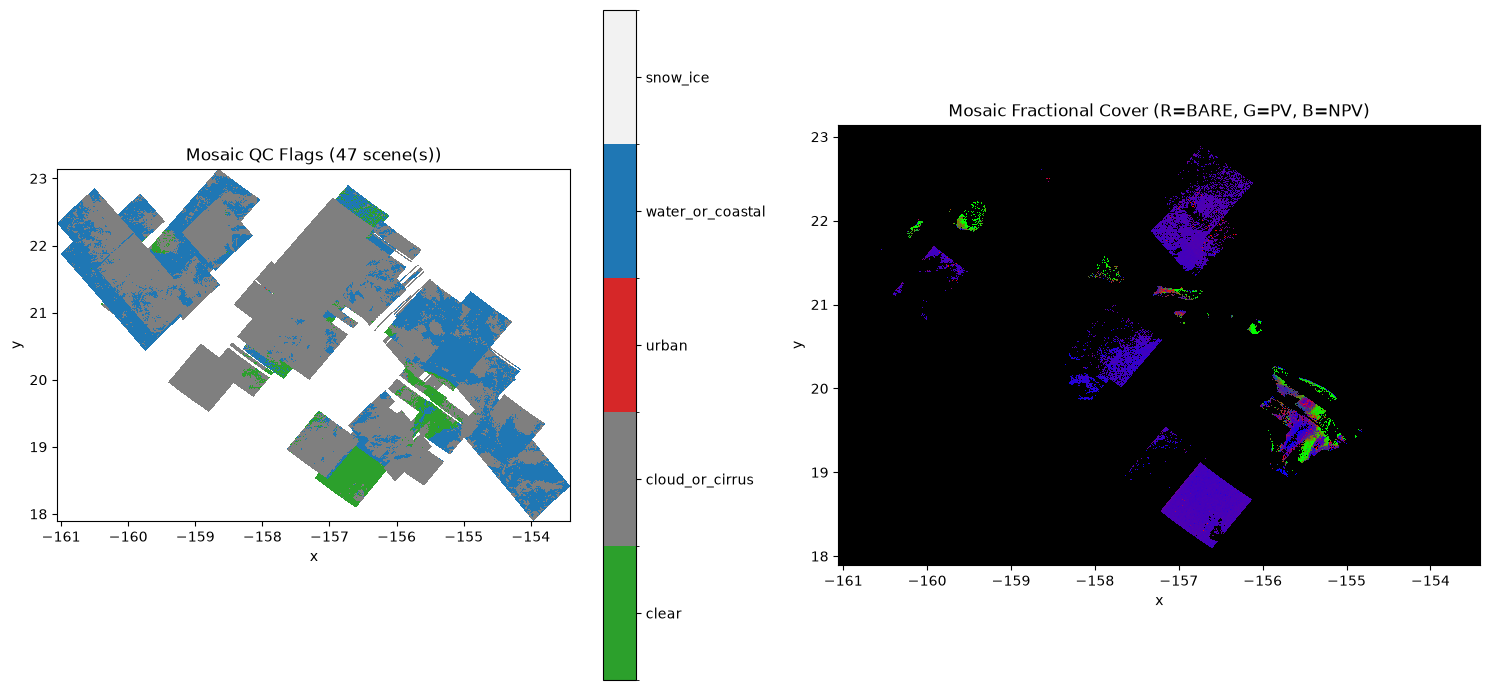

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = ds_mosaic["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title(f"Mosaic QC Flags ({len(granules)} scene(s))")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

rgb_mosaic = xr.concat(
    [ds_mosaic["bare"].fillna(0), ds_mosaic["pv"].fillna(0), ds_mosaic["npv"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb_mosaic.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Mosaic Fractional Cover (R=BARE, G=PV, B=NPV)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [13]:
print(ds_mosaic.nbytes / 1e9, "GB")
print(ds_mosaic.dims)

7.107691972 GB
FrozenMappingWarningOnValuesAccess({'x': 14107, 'y': 9689})


#basically this tells us how large the mosaic is; which is why the whole thing kills the kernel and crashes before it can produce any kind of plot
had to move it to 20 because it still crashed


In [ ]:
factor = 30  # try 20 if this still crashes, or 5 if you want more detail

def prep(band):
    return ds_mosaic[band].fillna(0).coarsen(x=factor, y=factor, boundary="trim").mean()

rgb_mosaic = xr.concat([prep("bare"), prep("pv"), prep("npv")], dim="band").transpose("y", "x", "band")

qc_small = ds_mosaic["qc"].coarsen(x=factor, y=factor, boundary="trim").mean()

Claude ^ gave us the code above to help us coarsen the plots so that it doesn't crash; if it does change the factor to 20 for further coarsening 
so run this line of code first, then, run the plot of code

In [3]:
print(ds_mosaic.chunks)

NameError: name 'ds_mosaic' is not defined

So this will be where I'm refining my shit  using Claude again because I don't my stuff to crash...


In [14]:
print(type(ds_mosaic["qc"].data))

<class 'numpy.ndarray'>


Okay so when I told Claude that output above it told me this:
- Your entire 7.1 GB is already loaded into RAM before you even start coarsening. Every operation after that (.fillna(), .coarsen(), .astype(), xr.concat()) creates a new copy in memory rather than working lazily/chunk-by-chunk. So your actual peak memory usage during that coarsening block is likely 2-4x the base 7GB, easily:
        - Ex: fillna(0) → new array copy (~7GB again)
        - Ex: .coarsen().mean() → needs the pre-coarsened array in memory to compute over
        - Ex: xr.concat([...]) for 3 bands → holds all 3 uncoarsened arrays simultaneously before/during concat

So what we're going to do is:
- 1. Convert to Dask before doing anything else. This is the real fix, not just a workaround. Rechunking into Dask lets each operation work on small pieces at a time instead of holding the whole thing in memory:

In [15]:
ds_mosaic = ds_mosaic.chunk({"x": 1024, "y": 1024})

- 2. Then your original coarsening code will actually stay lazy and memory-efficient:

In [10]:
factor = 30  # try 20 if this still crashes, or 5 if you want more detail

def prep(band):
    return ds_mosaic[band].fillna(0).coarsen(x=factor, y=factor, boundary="trim").mean()

rgb_mosaic = xr.concat([prep("bare"), prep("pv"), prep("npv")], dim="band").transpose("y", "x", "band")
rgb_mosaic = rgb_mosaic.compute()

qc_small = ds_mosaic["qc"].coarsen(x=factor, y=factor, boundary="trim").mean().compute()

Then, i went back to run the code to plot which is this: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


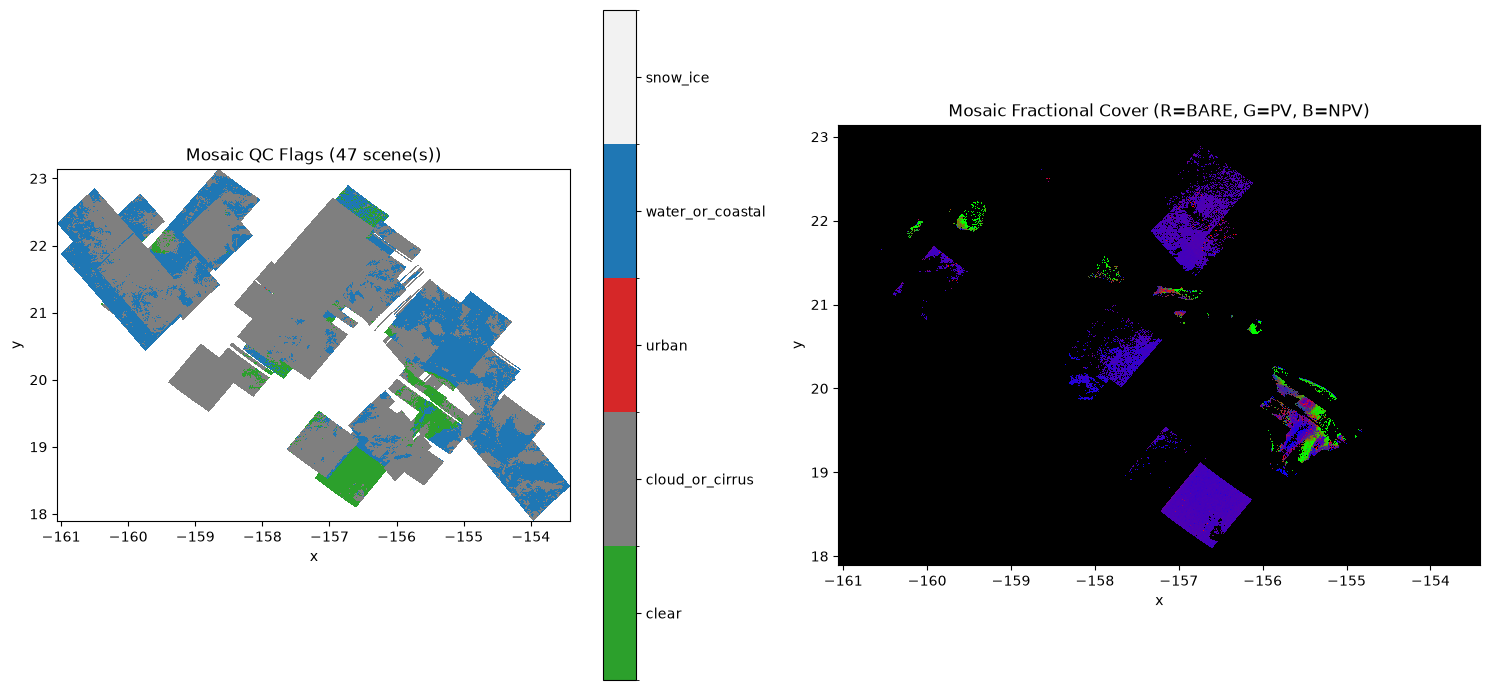

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = ds_mosaic["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title(f"Mosaic QC Flags ({len(granules)} scene(s))")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

rgb_mosaic = xr.concat(
    [ds_mosaic["bare"].fillna(0), ds_mosaic["pv"].fillna(0), ds_mosaic["npv"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb_mosaic.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Mosaic Fractional Cover (R=BARE, G=PV, B=NPV)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

Export Mosaic (Analysis-Ready GeoTIFFs)

In [12]:
export_dir = os.path.join("data", "processed")
os.makedirs(export_dir, exist_ok=True)

for var in mosaic_vars:
    out_path = os.path.join(export_dir, f"emit_2023HIfcov_mosaic_{var}.tif")
    da = ds_mosaic[var]
    # qc is integer-dtype -- reuse its native -9999 nodata sentinel (see flag_labels
    # comment above) since NaN isn't representable in an int raster. Everything else
    # (fraction + uncertainty bands) is float, so NaN is fine.
    nodata = -9999 if var == "qc" else np.nan
    # Both attrs and encoding can carry a stale _FillValue (attrs from write_nodata()
    # below, encoding inherited from open_rasterio(masked=True) via merge_arrays) --
    # to_raster()'s CF encoder refuses to reconcile them itself, so clear both first.
    da.attrs.pop("_FillValue", None)
    da.encoding.pop("_FillValue", None)
    if var == "qc":
        da = da.fillna(nodata).astype("int16")
    da.rio.write_nodata(nodata, inplace=True)
    da.rio.to_raster(out_path, compress="LZW")
    print(f"Wrote {out_path}")

Wrote data/processed/emit_2023HIfcov_mosaic_qc.tif
Wrote data/processed/emit_2023HIfcov_mosaic_pv.tif
Wrote data/processed/emit_2023HIfcov_mosaic_npv.tif
Wrote data/processed/emit_2023HIfcov_mosaic_bare.tif
Wrote data/processed/emit_2023HIfcov_mosaic_pv_unc.tif
Wrote data/processed/emit_2023HIfcov_mosaic_npv_unc.tif
Wrote data/processed/emit_2023HIfcov_mosaic_bare_unc.tif


Preliminary Stats

In [28]:
# Per-band descriptive stats (fractions are unitless 0-1; uncertainty is in the same units)
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var]
    unc = ds_mosaic[f"{var}_unc"]
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

# Dominant cover class per pixel (whichever of PV/NPV/BARE has the highest fraction there)
stacked = xr.concat(
    [ds_mosaic["pv"], ds_mosaic["npv"], ds_mosaic["bare"]], dim="band"
).assign_coords(band=["pv", "npv", "bare"])
dominant = stacked.idxmax(dim="band")

n_valid = int(dominant.notnull().sum())
print(f"\nDominant cover class ({n_valid} clear pixels):")
for label in ["pv", "npv", "bare"]:
    n = int((dominant == label).sum())
    print(f"  {label:5s}: {n:8d}  ({100 * n / n_valid:5.1f}%)")

NotImplementedError: The da.nanmedian function only works along an axis or a subset of axes.  The full algorithm is difficult to do in parallel

#didn't work so we asked claude for another code to do so

In [29]:
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var]
    unc = ds_mosaic[f"{var}_unc"]
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(dim=data.dims, skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

NotImplementedError: The da.nanmedian function only works along an axis or a subset of axes.  The full algorithm is difficult to do in parallel

also didn't work

In [30]:
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var]
    unc = ds_mosaic[f"{var}_unc"]
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(dim=data.dims, skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

NotImplementedError: The da.nanmedian function only works along an axis or a subset of axes.  The full algorithm is difficult to do in parallel

Also didn't work

In [31]:
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var].compute()
    unc = ds_mosaic[f"{var}_unc"].compute()
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.0974  0.0000  0.2537  0.0  1.0            0.0681
npv   0.6248  0.7112  0.2385  0.0  1.0            0.3759
bare  0.2778  0.2794  0.1278  0.0  1.0            0.3473


SUCCESS!!! AYYEEE

In [32]:
# Dominant cover class per pixel (whichever of PV/NPV/BARE has the highest fraction there)
stacked = xr.concat(
    [ds_mosaic["pv"], ds_mosaic["npv"], ds_mosaic["bare"]], dim="band"
).assign_coords(band=["pv", "npv", "bare"])
dominant = stacked.idxmax(dim="band")

n_valid = int(dominant.notnull().sum())
print(f"\nDominant cover class ({n_valid} clear pixels):")
for label in ["pv", "npv", "bare"]:
    n = int((dominant == label).sum())
    print(f"  {label:5s}: {n:8d}  ({100 * n / n_valid:5.1f}%)")


Dominant cover class (6464160 clear pixels):
  pv   :   626232  (  9.7%)
  npv  :  5462751  ( 84.5%)
  bare :   375177  (  5.8%)


To push your Jupyter notebook now that it's here
1. check your status:
a. git status
2. then add with the filename
b. git add <filename>
3. commit to the file, then describe it
c. git commit -m <describe it>
4. now push it diva
d. git push

#Update: We will be masking out the ocean from the GeoTIFF files 

#Applying this to your mosaic QC file
Since our emit_2023HIfcov_mosaic_qc.tif file was built from these per-scene QC files (value 3 = water/coastal), you can mask oceans out like this:

In [13]:
import rasterio
import numpy as np

qc_path = "data/processed/emit_2023HIfcov_mosaic_qc.tif"

with rasterio.open(qc_path) as src:
    qc = src.read(1)
    profile = src.profile

# Boolean mask: True where it's water/coastal (ocean)
ocean_mask = (qc == 3)

# Example: apply this mask to your fractional cover data to exclude oceans
# (assuming ds_mosaic[var] is one of your frcov variables, same shape as qc)
frcov_masked = np.where(ocean_mask, np.nan, ds_mosaic[var].values)

#Option A: Just visualize it directly in the notebook (no file needed)
Since frcov_masked is already a NumPy array sitting in memory, you can plot it immediately:

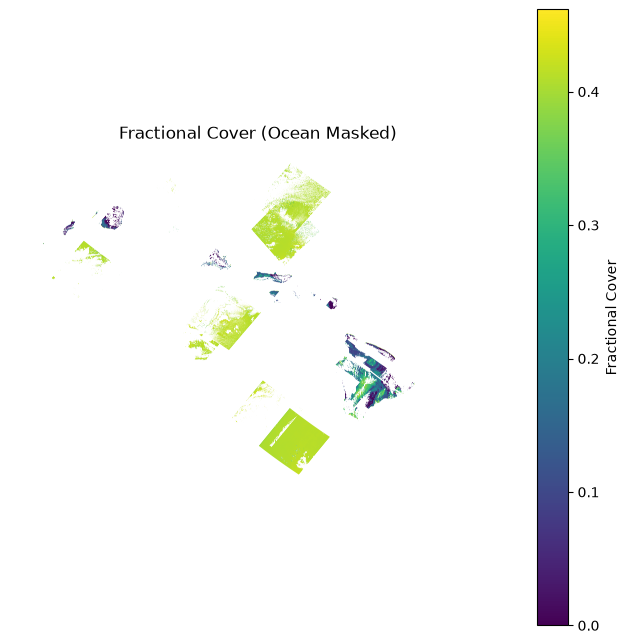

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(frcov_masked, cmap="viridis")
plt.colorbar(label="Fractional Cover")
plt.title("Fractional Cover (Ocean Masked)")
plt.axis("off")
plt.show()

What i liked about this is that it did its job, but it doesn't really tell us what these colors mean; so i asked claude what other way can we change this plot to depict the QC flags so that these colors convey meaning!

visualize the QC array itself (not the continuous fractional cover values) with distinct colors per category, plus a legend that only shows the QC flags actually present in the masked image. Since QC values are categorical (0, 1, 2, 3, 4, -9999), a plain viridis colorbar isn't the right tool — you want a discrete colormap + legend instead.

QC values present after masking: [np.int16(0), np.int16(1), np.int16(2), np.int16(3), np.int16(4)]


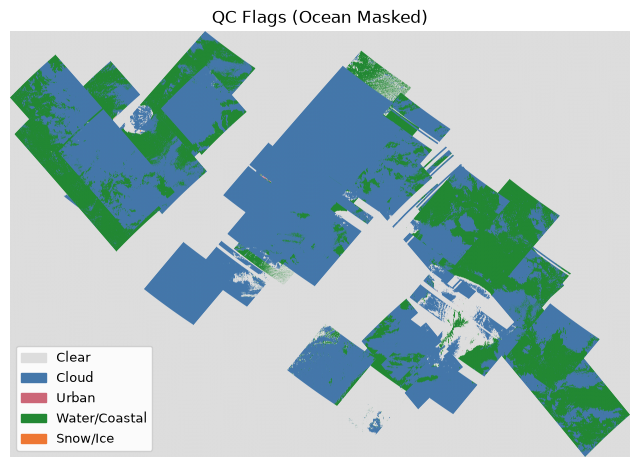

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# --- Define QC flag meanings and colors ---
qc_labels = {
    0: ("Clear", "#dddddd"),
    1: ("Cloud", "#4477AA"),
    2: ("Urban", "#CC6677"),
    3: ("Water/Coastal", "#228833"),
    4: ("Snow/Ice", "#EE7733"),
}

# --- Find which QC values are actually present in your masked array ---
present_values = sorted(v for v in np.unique(qc) if v in qc_labels)
print("QC values present after masking:", present_values)

# --- Build a colormap using only the present categories ---
colors = [qc_labels[v][1] for v in present_values]
labels = [qc_labels[v][0] for v in present_values]
cmap = ListedColormap(colors)

# BoundaryNorm needs bin edges between each category
bounds = present_values + [present_values[-1] + 1]
norm = BoundaryNorm(bounds, cmap.N)

# --- Plot ---
plt.figure(figsize=(8, 8))
plt.imshow(qc, cmap=cmap, norm=norm)
plt.title("QC Flags (Ocean Masked)")
plt.axis("off")

# --- Legend instead of a colorbar, since these are categories not a gradient ---
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
plt.legend(handles=patches, loc="lower left", fontsize=9, framealpha=0.9)

plt.show()

"rasterizing" the hawaii shapefile to match our EMIT Grid which is basically converting vector shapes into a pixel/grid 

In [17]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import numpy as np

# --- Load the shapefile (still needs geopandas) ---
gdf = gpd.read_file("/Users/gillopez/Downloads/Coastline/Coastline.shp")

# --- Load a reference raster to match resolution/extent/CRS ---
ref_path = "data/processed/emit_2023HIfcov_mosaic_qc.tif"
with rasterio.open(ref_path) as ref:
    ref_transform = ref.transform
    ref_shape = (ref.height, ref.width)
    ref_crs = ref.crs

# --- Reproject shapefile to match the raster's CRS ---
gdf = gdf.to_crs(ref_crs)

# --- Rasterize: pixels inside a polygon = 1, outside = 0 ---
mask = rasterize(
    [(geom, 1) for geom in gdf.geometry if not geom.is_empty],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype=np.uint8
)

print(mask.shape, np.unique(mask))

(9689, 14107) [0 1]


Clipping the QC Geotif using the shapefile

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask

# --- Paths ---
shp_path = "/Users/gillopez/Downloads/Coastline/Coastline.shp"  # from earlier download
qc_path = "data/processed/emit_2023HIfcov_mosaic_qc.tif"
out_path = "data/processed/emit_2023HIfcov_mosaic_qc_clipped.tif"

# --- Load shapefile ---
gdf = gpd.read_file(shp_path)

# --- Open raster and match CRS ---
with rasterio.open(qc_path) as src:
    raster_crs = src.crs

    # Reproject shapefile to match raster CRS if needed
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)

    # --- Clip ---
    out_image, out_transform = mask(
        src,
        gdf.geometry,
        crop=True,        # crop the raster extent to the shape's bounding box
        nodata=-9999,      # matches your QC nodata convention
        filled=True
    )
    out_meta = src.meta.copy()

# --- Update metadata to match clipped shape/transform ---
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": -9999
})

# --- Write clipped GeoTIFF ---
with rasterio.open(out_path, "w", **out_meta) as dst:
    dst.write(out_image)

print(f"Clipped raster saved to {out_path}")

Clipped raster saved to data/processed/emit_2023HIfcov_mosaic_qc_clipped.tif


Quick visual check

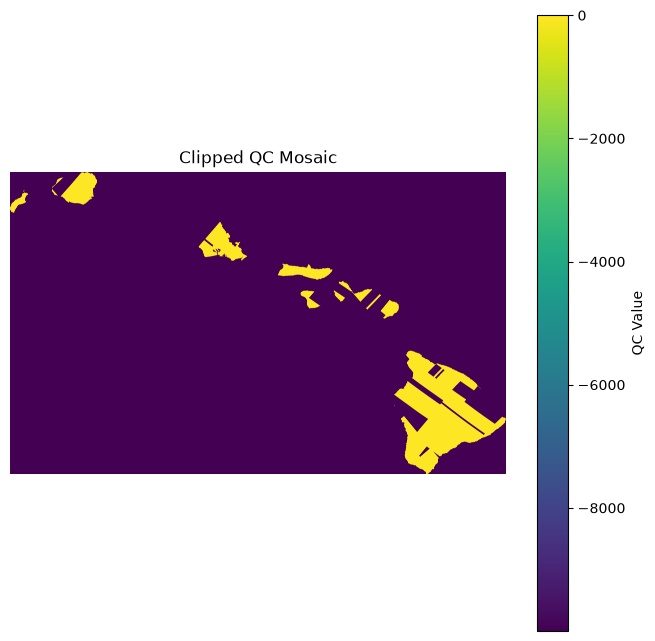

In [20]:
import matplotlib.pyplot as plt

with rasterio.open(out_path) as src:
    clipped = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(clipped, cmap="viridis")
plt.colorbar(label="QC Value")
plt.title("Clipped QC Mosaic")
plt.axis("off")
plt.show()

Fix: mask out nodata + use the discrete/categorical plotting approach from earlier

QC values present: [np.int16(0), np.int16(1), np.int16(2), np.int16(3), np.int16(4)]


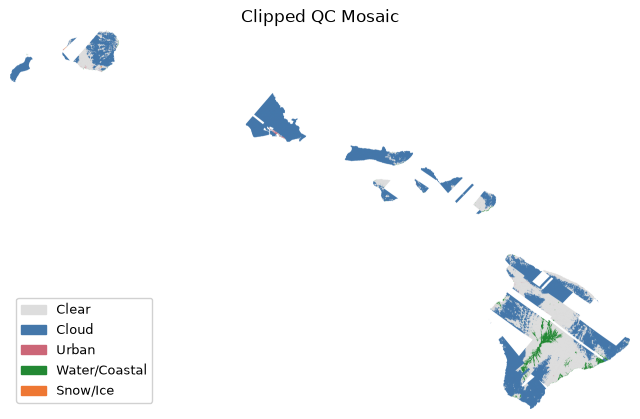

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio

with rasterio.open(out_path) as src:  # your clipped file
    qc = src.read(1)
    nodata_val = src.nodata

# --- Mask out nodata so it doesn't dominate the color scale ---
qc_masked = np.ma.masked_equal(qc, nodata_val)

# --- QC categories ---
qc_labels = {
    0: ("Clear", "#dddddd"),
    1: ("Cloud", "#4477AA"),
    2: ("Urban", "#CC6677"),
    3: ("Water/Coastal", "#228833"),
    4: ("Snow/Ice", "#EE7733"),
}

present_values = sorted(v for v in np.unique(qc_masked.compressed()) if v in qc_labels)
print("QC values present:", present_values)

colors = [qc_labels[v][1] for v in present_values]
labels = [qc_labels[v][0] for v in present_values]
cmap = ListedColormap(colors)
cmap.set_bad(color="white")  # nodata shows as white instead of a "color"

bounds = present_values + [present_values[-1] + 1]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8, 8))
plt.imshow(qc_masked, cmap=cmap, norm=norm)
plt.title("Clipped QC Mosaic")
plt.axis("off")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
plt.legend(handles=patches, loc="lower left", fontsize=9, framealpha=0.9)
plt.show()

1. Clip and mask each fractional cover band

In [23]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

# --- Paths ---
shp_path = "/Users/gillopez/Downloads/Coastline/Coastline.shp"  # from earlier download
qc_path = "data/processed/emit_2023HIfcov_mosaic_qc.tif"
bare_path = "data/processed/emit_2023HIfcov_mosaic_bare.tif"
pv_path = "data/processed/emit_2023HIfcov_mosaic_pv.tif"
npv_path = "data/processed/emit_2023HIfcov_mosaic_npv.tif"

gdf = gpd.read_file(shp_path)

def clip_raster(path, gdf, nodata_val):
    with rasterio.open(path) as src:
        gdf_reproj = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        out_image, out_transform = mask(
            src, gdf_reproj.geometry, crop=True, nodata=nodata_val, filled=True
        )
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": nodata_val
        })
    return out_image[0], out_meta  # single band

# --- Clip QC and each fractional cover band ---
qc_clipped, qc_meta = clip_raster(qc_path, gdf, -9999)
bare_clipped, bare_meta = clip_raster(bare_path, gdf, np.nan)
pv_clipped, pv_meta = clip_raster(pv_path, gdf, np.nan)
npv_clipped, npv_meta = clip_raster(npv_path, gdf, np.nan)

print("Shapes match:", qc_clipped.shape == bare_clipped.shape == pv_clipped.shape == npv_clipped.shape)

Shapes match: True


2. Apply the ocean mask (QC == 3) on top of the clip

In [24]:
# --- Ocean mask: True where water/coastal ---
ocean_mask = (qc_clipped == 3)

# --- Apply mask to each band ---
bare_masked = np.where(ocean_mask, np.nan, bare_clipped)
pv_masked = np.where(ocean_mask, np.nan, pv_clipped)
npv_masked = np.where(ocean_mask, np.nan, npv_clipped)

3. Build and normalize the RGB composite

In [25]:
def normalize(band):
    band = np.nan_to_num(band, nan=0.0)
    band_min, band_max = np.nanmin(band), np.nanmax(band)
    if band_max - band_min == 0:
        return np.zeros_like(band)
    return (band - band_min) / (band_max - band_min)

r = normalize(bare_masked)  # BARE
g = normalize(pv_masked)    # PV
b = normalize(npv_masked)   # NPV

rgb = np.dstack([r, g, b])

4. Plot it

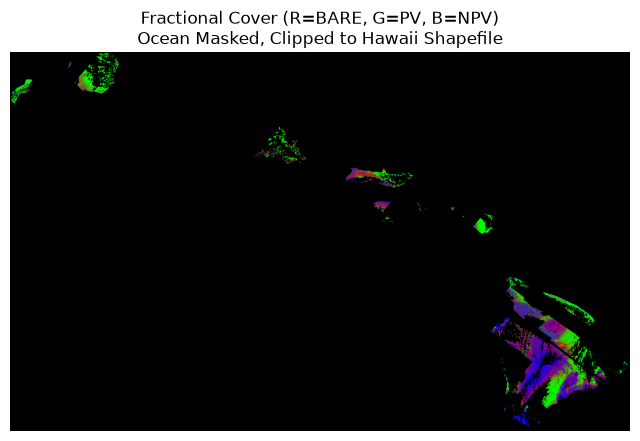

In [26]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("Fractional Cover (R=BARE, G=PV, B=NPV)\nOcean Masked, Clipped to Hawaii Shapefile")
plt.axis("off")
plt.show()

we're going to add the default coordinate extent to the RGB plot ^ above

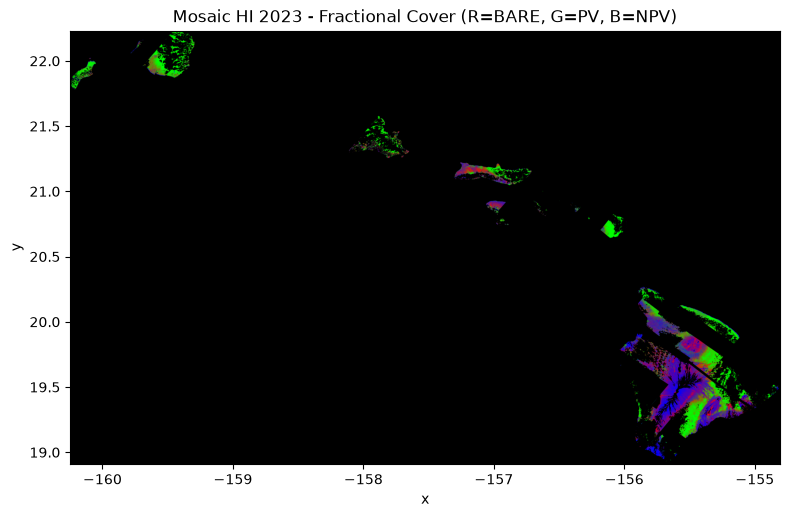

In [28]:
import matplotlib.pyplot as plt

# --- Get geographic bounds from the clipped raster's metadata ---
transform = bare_meta["transform"]
height, width = bare_masked.shape

left = transform.c
top = transform.f
right = left + width * transform.a
bottom = top + height * transform.e  # transform.e is negative

extent = [left, right, bottom, top]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, extent=extent)
ax.set_title("Mosaic HI 2023 - Fractional Cover (R=BARE, G=PV, B=NPV)")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()

#let's see if this code of stats will work now that we've masked out oceans

In [29]:
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var].compute()
    unc = ds_mosaic[f"{var}_unc"].compute()
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.0974  0.0000  0.2537  0.0  1.0            0.0681
npv   0.6248  0.7112  0.2385  0.0  1.0            0.3759
bare  0.2778  0.2794  0.1278  0.0  1.0            0.3473


#nvm it's the same stats, i'm going to try to see if i can make a % annual change across all HI bands 

1. we will be storing the statistics from each notebook into 1 csv file!

In [30]:
import pandas as pd
import os

# --- Your existing stats code ---
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var].compute()
    unc = ds_mosaic[f"{var}_unc"].compute()
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

# --- Flatten into one row for the shared summary file ---
year = 2023      # <-- change per notebook
region = "HI"    # <-- change to "CA" in the CA notebooks

summary_row = {"year": year, "region": region}
for band in ["pv", "npv", "bare"]:
    summary_row[f"{band}_mean"] = stats_df.loc[band, "mean"]

summary_path = "data/processed/landcover_mean_summary.csv"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)

if os.path.exists(summary_path):
    df_existing = pd.read_csv(summary_path)
    df_existing = df_existing[~((df_existing["year"] == year) & (df_existing["region"] == region))]
    df_updated = pd.concat([df_existing, pd.DataFrame([summary_row])], ignore_index=True)
else:
    df_updated = pd.DataFrame([summary_row])

df_updated.to_csv(summary_path, index=False)
print(f"Saved {region} {year} summary")
print(df_updated)

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.0974  0.0000  0.2537  0.0  1.0            0.0681
npv   0.6248  0.7112  0.2385  0.0  1.0            0.3759
bare  0.2778  0.2794  0.1278  0.0  1.0            0.3473
Saved HI 2023 summary
   year region   pv_mean  npv_mean  bare_mean
0  2023     HI  0.097437  0.624778   0.277785
